In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/13
    print("準備完了！このまま下のセルを実行できます。")

# 第13章 グラフニューラルネットワーク (Graph Neural Networks)
## 13.2 ニューラル・メッセージパッシング (Neural Message-Passing)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第13章「グラフニューラルネットワーク」第13.2節「ニューラル・メッセージパッシング (Neural Message-Passing)」の全7小節（13.2.1 〜 13.2.7）の完全な理論解説、数学的定式化（式 13.8 〜 式 13.23、Algorithm 13.1）、教科書図版（Figure 13.3 〜 13.4 全2枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **13.2.1 畳み込みフィルタ (Convolutional Filters, Figure 13.3, 式 13.8 〜 13.9)**
   - 画像CNNの局所フィルタとグラフ構造計算の対応関係
   - 標準CNNフィルタ（式 13.8）：局所パッチ上の線形結合と非同変性
   - グラフ同変フィルタ（式 13.9）：$w_{\text{self}}$ と近傍共有重み $w_{\text{neigh}}$
   - ノード順序置換に対する感度検証（標準CNNの破綻とグラフ畳み込みの置換同変性）
3. **13.2.2 グラフ畳み込みネットワークとメッセージパッシング (GCN & Algorithm 13.1, 式 13.10 〜 13.11)**
   - 2段階メッセージパッシング枠組み (Gilmer et al., 2017)
   - 集約ステージ (Aggregation, 式 13.10): $z_n^{(l)} = \text{Aggregate}(\{h_m^{(l)} : m \in \mathcal{N}(n)\})$
   - 更新ステージ (Update, 式 13.11): $h_n^{(l+1)} = \text{Update}(h_n^{(l)}, z_n^{(l)})$
   - 多層スタックによる深層表現学習と可変サイズグラフへの適応
4. **13.2.3 集約演算子 (Aggregation Operators, Figure 13.4, 式 13.12 〜 13.15)**
   - 和集約 (Summation, 式 13.12)
   - 平均集約 (Mean / Average, 式 13.13)
   - 対称正規化集約 (Symmetric Normalized, Kipf & Welling 2016, 式 13.14)
   - 要素ごと最大値・最小値プーリング (Max/Min pooling)
   - Deep Sets / MLPパラメータ化集約 (Zaheer et al. 2017, 式 13.15) と置換不変関数の万能近似性
   - 受容野 (Receptive Field) の層方向拡大（Figure 13.4）：ホップ数 $1 \to 3 \to 8$ ノードの伝播
5. **13.2.4 更新演算子 (Update Operators, 式 13.16 〜 13.19)**
   - 線形結合更新（式 13.16）: $f(W_{\text{self}} h_n^{(l)} + W_{\text{neigh}} z_n^{(l)} + b)$
   - 重み共有更新（式 13.17）: $f(W_{\text{neigh}} \sum_{m \in \mathcal{N}(n) \cup \{n\}} h_m^{(l)} + b)$
   - 行列表現（式 13.18）: $H^{(l+1)} = \sigma(\widetilde{A}_{\text{norm}} H^{(l)} W^{(l)})$
   - 層レベル置換同変性の数学的証明と数値検証（式 13.19）
6. **13.2.5 ノード分類 (Node Classification, 式 13.20 〜 13.21)**
   - ソフトマックス出力層（式 13.20）
   - 半教師あり交差エントロピー損失（式 13.21）
   - ノード集合の分割：訓練ノード $\mathcal{V}_{\text{train}}$、導入的ノード $\mathcal{V}_{\text{trans}}$、帰納的ノード $\mathcal{V}_{\text{induct}}$
   - 2層GCNによる空手クラブ (Zachary's Karate Club) グラフの半教師ありコミュニティ分類学習
7. **13.2.6 エッジ分類・リンク予測 (Edge Classification, 式 13.22)**
   - 内積シグモイド表現（式 13.22）: $p(n, m) = \sigma(h_n^T h_m)$
   - 双線形形式 $p(n, m) = \sigma(h_n^T W_{\text{edge}} h_m)$
   - ソーシャルネットワーク推薦・分子結合予測への応用
8. **13.2.7 グラフ全体分類 (Graph Classification, 式 13.23)**
   - 置換不変な大域読み出しプーリング（式 13.23）: $y = f(\sum_{n \in \mathcal{V}} h_n^{(L)})$
   - サイクルグラフ vs スターグラフのグラフ分類実験
9. **まとめと次節 13.3（一般化グラフネットワーク）への展望**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "13" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.machine_learning_on_graphs import Graph, build_permutation_matrix
from common.neural_message_passing import (
    relu,
    d_relu,
    sigmoid,
    softmax,
    conv2d_filter_standard,
    conv2d_filter_equivariant,
    check_conv_permutation_sensitivity,
    aggregate_sum,
    aggregate_mean,
    aggregate_norm,
    aggregate_max,
    aggregate_min,
    aggregate_deep_sets,
    MLP,
    update_linear,
    update_shared,
    update_concat,
    MessagePassingLayer,
    GCNLayer,
    GraphConvolutionalNetwork,
    NodeClassifier,
    EdgeClassifier,
    GraphClassifier,
    check_mpnn_permutation_equivariance,
    check_graph_readout_invariance,
    compute_receptive_field,
    create_figure_13_4_graph,
    create_karate_club_graph,
    create_synthetic_graph_dataset,
    generate_figure_13_3,
    generate_figure_13_4,
)

setup_style()
print("Common neural_message_passing modules successfully loaded.")


Common neural_message_passing modules successfully loaded.


---
## 13.2.1 畳み込みフィルタ (Convolutional Filters)

### 1. 理論的背景：画像畳み込みからグラフメッセージパッシングへ
画像に対する畳み込みニューラルネットワーク（CNN, 第10章）は、ピクセルの局所パッチに対して受容野を形成し、空間的な重み共有を行うことで並進同変性を獲得します。画像は、ピクセルをノード、隣接する上下左右・斜めのピクセル間をエッジとする特殊な規則的グラフ（Grid Graph）とみなすことができます。

サイズ $3 \times 3$ のフィルタを用いた第 $l$ 層から第 $l+1$ 層への単一ピクセル $i$ における畳み込み演算は次式で表されます（式 13.8）：

$$
z_i^{(l+1)} = f\left( \sum_{j} w_j z_j^{(l)} + b \right) \tag{13.8}
$$

ここで $f(\cdot)$ は ReLU などの微分可能な非線形活性化関数であり、総和 $\sum_j$ は層 $l$ の局所パッチ内の 9 個のピクセルにわたって取られます。

### 2. ノード順序の任意性と置換同変性の要請
式 (13.8) では、重みベクトル $\mathbf{w} = (w_1, \dots, w_9)^T$ が各ピクセルの相対位置（左上、上、右上など）に固有の値を持つため、ピクセルのインデックス順序の入れ替えに対して**不変でも同変でもありません**。

任意のグラフ構造データに適用するためには、ノードのラベリング順序に依存しない演算が必要です。そこで、中心ノード $i$ 自身の寄与（自己重み $w_{\text{self}}$）と、近傍ノード $\mathcal{N}(i)$ からの寄与（近傍共有重み $w_{\text{neigh}}$）を分離します（式 13.9）：

$$
z_i^{(l+1)} = f\left( w_{\text{neigh}} \sum_{j \in \mathcal{N}(i)} z_j^{(l)} + w_{\text{self}} z_i^{(l)} + b \right) \tag{13.9}
$$

式 (13.9) の第 1 項 $\sum_{j \in \mathcal{N}(i)} z_j^{(l)}$ は近傍の総和であり、近傍ノードの順序付けに完全に不変です。全ノード $i$ に対して同一のパラメータ $(w_{\text{neigh}}, w_{\text{self}}, b)$ を同期適用することで、ネットワーク層全体として**置換同変性 (Permutation Equivariance)** が保証されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_3_convolutional_filters.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_3_convolutional_filters.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/Figure_13_3.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_13_3.png


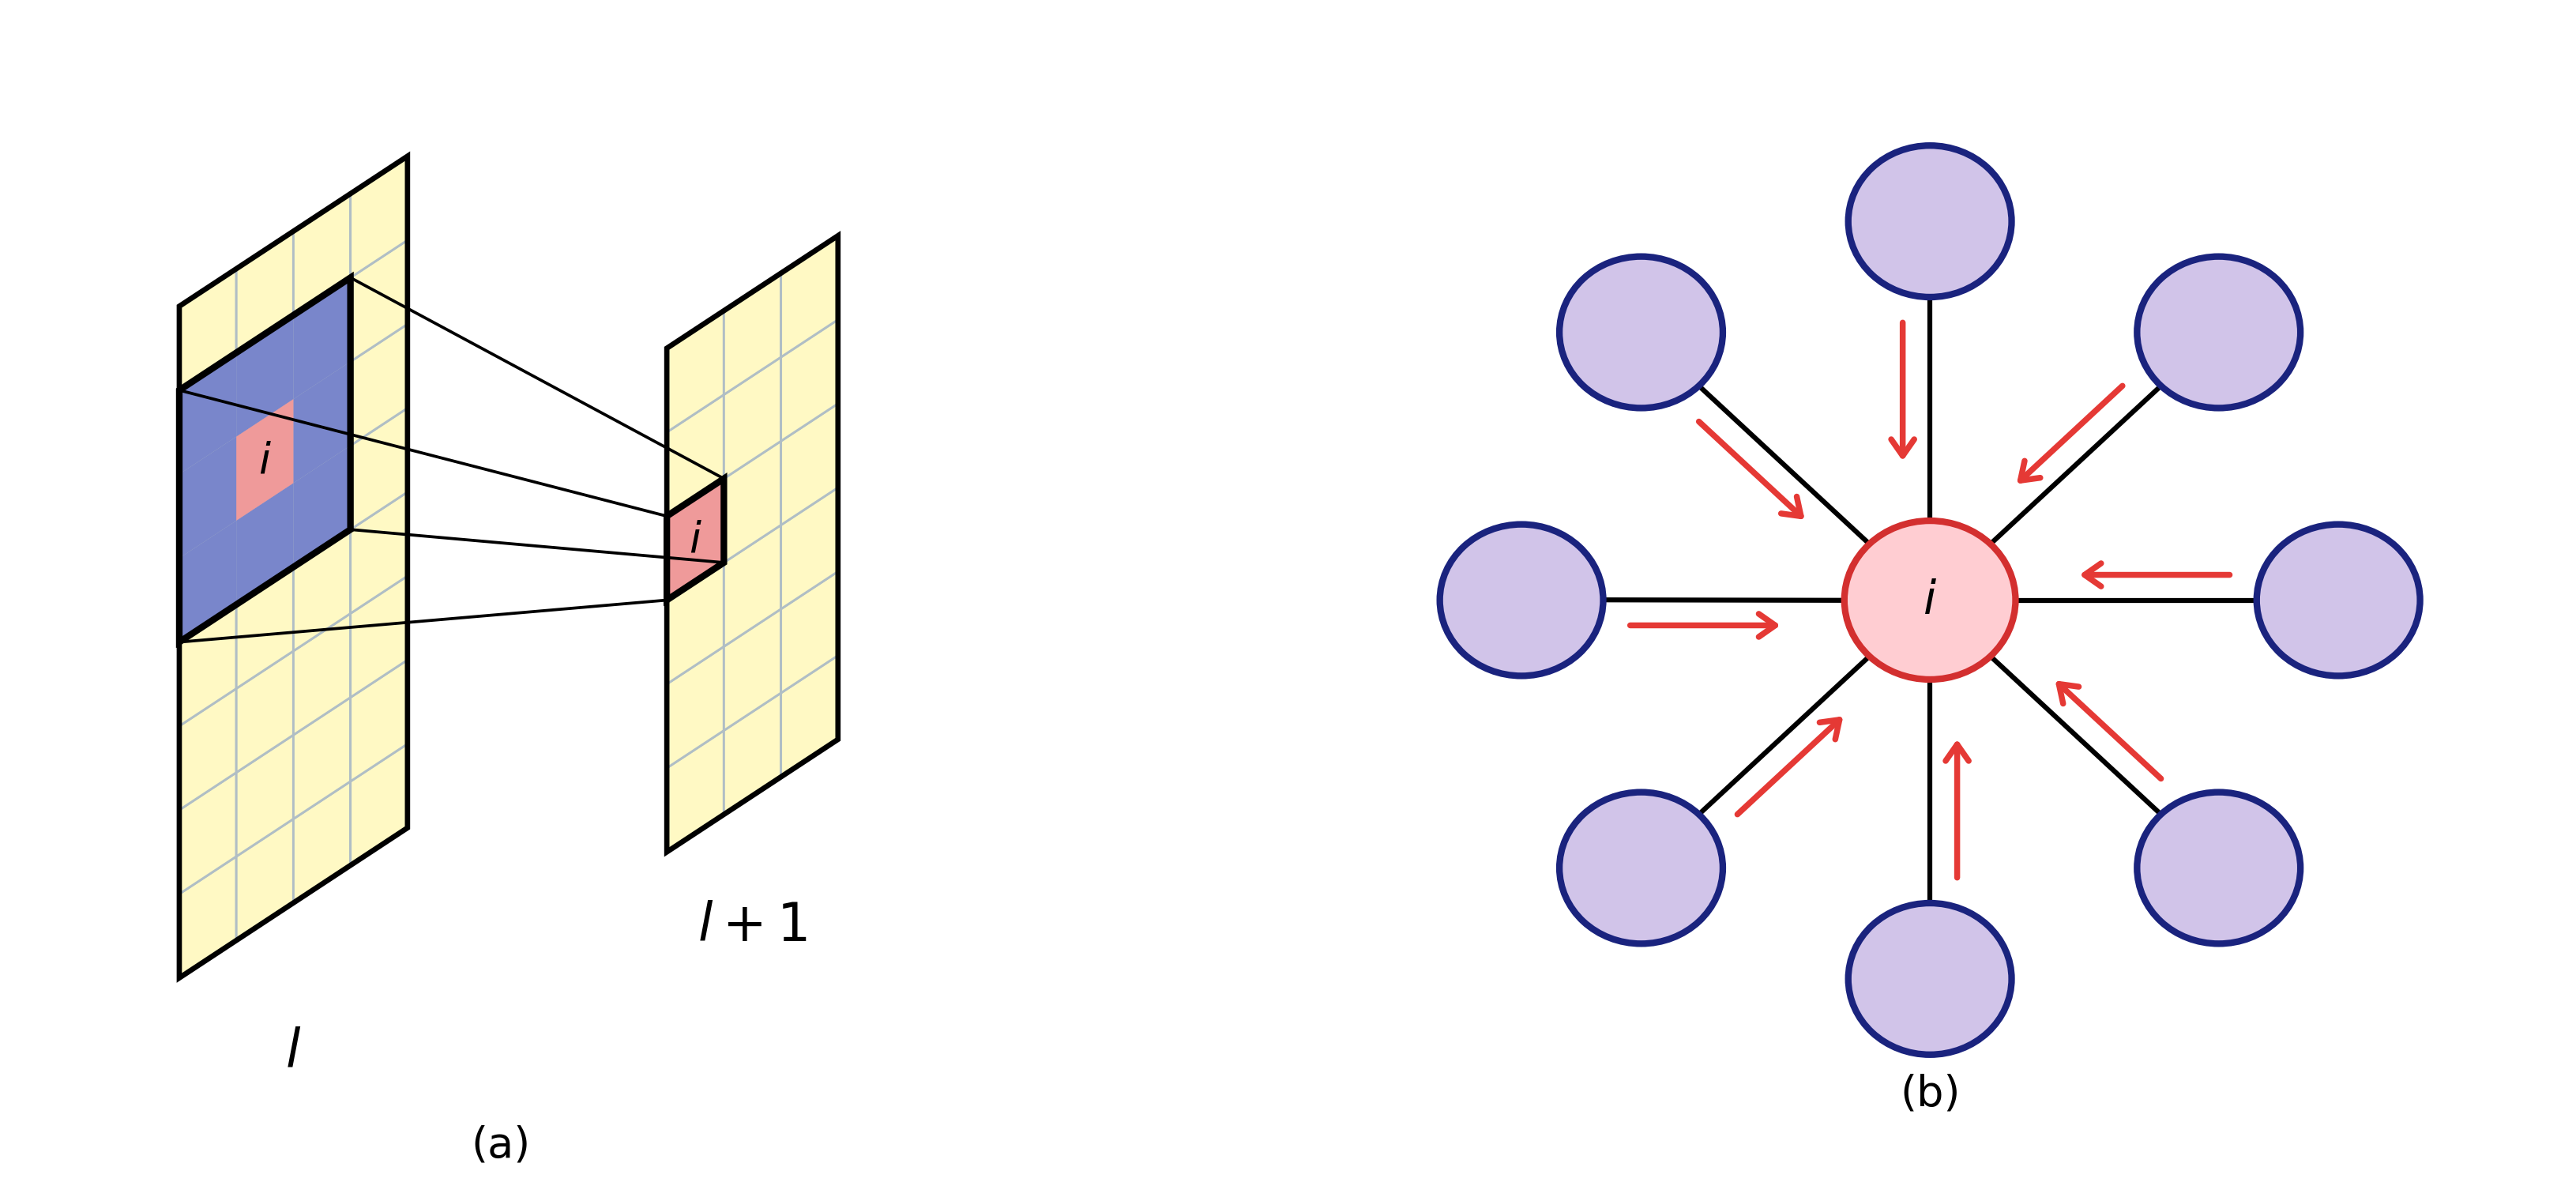

In [2]:
# 教科書 図 13.3 の生成と表示
fig13_3 = generate_figure_13_3()
plt.show()


In [3]:
# 式 (13.8) と 式 (13.9) の置換感度検証
# 3x3 局所画像パッチ
patch_data = np.array([
    [1.2, 2.4, 0.8],
    [3.1, 5.0, 1.7],
    [4.2, 0.5, 2.9]
])
weights_cnn = np.array([
    [0.1, -0.2, 0.5],
    [0.3,  1.0, -0.4],
    [0.8,  0.2, -0.1]
])

res = check_conv_permutation_sensitivity(
    patch_values=patch_data,
    weights_std=weights_cnn,
    w_self=1.0,
    w_neigh=0.25,
    bias=0.1
)

print("=== 畳み込みフィルタの置換感度比較 ===")
print(f"標準CNN (式 13.8) 元パッチ出力: {res['std_orig']:.6f}")
print(f"標準CNN (式 13.8) 置換パッチ出力: {res['std_perm']:.6f}")
print(f"標準CNN 出力差分: {res['std_diff']:.6e} (非同変：順序変更で出力が変動)")
print()
print(f"グラフ同変フィルタ (式 13.9) 元出力: {res['graph_orig']:.6f}")
print(f"グラフ同変フィルタ (式 13.9) 置換出力: {res['graph_perm']:.6f}")
print(f"グラフ同変フィルタ 出力差分: {res['graph_diff']:.6e} (完全同変：順序入替に対して不変)")
assert res['is_graph_equivariant'], "Graph filter must be permutation equivariant!"


=== 畳み込みフィルタの置換感度比較 ===
標準CNN (式 13.8) 元パッチ出力: 8.560000
標準CNN (式 13.8) 置換パッチ出力: 7.580000
標準CNN 出力差分: 9.800000e-01 (非同変：順序変更で出力が変動)

グラフ同変フィルタ (式 13.9) 元出力: 9.300000
グラフ同変フィルタ (式 13.9) 置換出力: 9.300000
グラフ同変フィルタ 出力差分: 0.000000e+00 (完全同変：順序入替に対して不変)


---
## 13.2.2 グラフ畳み込みネットワーク (Graph Convolutional Networks)

### 1. 2段階メッセージパッシング枠組み (Algorithm 13.1)
グラフ上の深層学習において、第 $l$ 層の各ノード $n$ の埋め込みベクトルを $\mathbf{h}_n^{(l)} \in \mathbb{R}^{D}$（初期値 $\mathbf{h}_n^{(0)} = \mathbf{x}_n$）とします。

式 (13.9) の構造を一般化すると、各処理層は以下の 2 つの連続するステージに分解できます：

1. **集約ステージ (Aggregation)** (式 13.10):
   各ノード $n$ について、近傍ノード群からのメッセージを集約して新ベクトル $\mathbf{z}_n^{(l)}$ を生成する：
   $$
   \mathbf{z}_n^{(l)} = \text{Aggregate}\left( \left\{ \mathbf{h}_m^{(l)} : m \in \mathcal{N}(n) \right\} \right) \tag{13.10}
   $$

2. **更新ステージ (Update)** (式 13.11):
   集約された近傍情報 $\mathbf{z}_n^{(l)}$ と、ノード自身の現在の埋め込み $\mathbf{h}_n^{(l)}$ を統合し、次層の埋め込みを計算する：
   $$
   \mathbf{h}_n^{(l+1)} = \text{Update}\left( \mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l)} \right) \tag{13.11}
   $$

この反復メッセージパッシング手続きを Algorithm 13.1 にまとめます。

```text
Algorithm 13.1: Simple message-passing neural network
Input:  Undirected graph G = (V, E)
        Initial node embeddings {h_n^{(0)} = x_n}
        Aggregate(·) function
        Update(·, ·) function
Output: Final node embeddings {h_n^{(L)}}

for l in {0, ..., L - 1} do:
    for each node n in V do:
        z_n^{(l)} = Aggregate({ h_m^{(l)} : m in N(n) })
        h_n^{(l+1)} = Update(h_n^{(l)}, z_n^{(l)})
return {h_n^{(L)}}
```


---
## 13.2.3 集約演算子 (Aggregation Operators)

### 1. 基本的な集約関数
集約関数 $\text{Aggregate}(\cdot)$ は、要素の順序に依存しない多重集合関数（置換不変関数）でなければなりません。

1. **和集約 (Summation)** (式 13.12):
   $$
   \text{Aggregate}\left( \left\{ \mathbf{h}_m^{(l)} : m \in \mathcal{N}(n) \right\} \right) = \sum_{m \in \mathcal{N}(n)} \mathbf{h}_m^{(l)} \tag{13.12}
   $$
   次数が高いノードほど大きな値を受け取るため、ノード間の次数差が大きいグラフ（スケールフリー網など）では数値不安定性を生じる場合があります。

2. **平均集約 (Mean / Average)** (式 13.13):
   $$
   \text{Aggregate}\left( \left\{ \mathbf{h}_m^{(l)} : m \in \mathcal{N}(n) \right\} \right) = \frac{1}{|\mathcal{N}(n)|} \sum_{m \in \mathcal{N}(n)} \mathbf{h}_m^{(l)} \tag{13.13}
   $$
   局所構造の大きさ（近傍数）を正規化により捨ててしまうため、表現力（1-WL テスト等）の観点で和集約より厳密に劣ることが証明されています (Hamilton, 2020)。

3. **対称正規化集約 (Symmetric Normalized)** (Kipf & Welling 2016, 式 13.14):
   $$
   \text{Aggregate}\left( \left\{ \mathbf{h}_m^{(l)} : m \in \mathcal{N}(n) \right\} \right) = \sum_{m \in \mathcal{N}(n)} \frac{\mathbf{h}_m^{(l)}}{\sqrt{|\mathcal{N}(n)| \cdot |\mathcal{N}(m)|}} \tag{13.14}
   $$
   送信元ノード $m$ と受信先ノード $n$ の次数の相乗平均で重み付け正規化します。

4. **Deep Sets / MLP パラメータ化集約** (Zaheer et al. 2017, 式 13.15):
   $$
   \text{Aggregate}\left( \left\{ \mathbf{h}_m^{(l)} : m \in \mathcal{N}(n) \right\} \right) = \text{MLP}_\theta \left( \sum_{m \in \mathcal{N}(n)} \text{MLP}_\phi \left( \mathbf{h}_m^{(l)} \right) \right) \tag{13.15}
   $$
   任意の置換不変集合関数に対する**万能近似器 (Universal Approximator)** であることが証明されています。

### 2. 受容野 (Receptive Field) の拡大 (Figure 13.4)
CNN において層を重ねるごとに受容野が広がるのと同様に、GNN においてもメッセージパッシングの反復によって、第 $L$ 層の単一ノードは $L$ ホップ以内の近傍ノード群の情報を受け取ります。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/fig_13_4_receptive_field_expansion.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_13_4_receptive_field_expansion.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/13/result/Figure_13_4.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_13_4.png


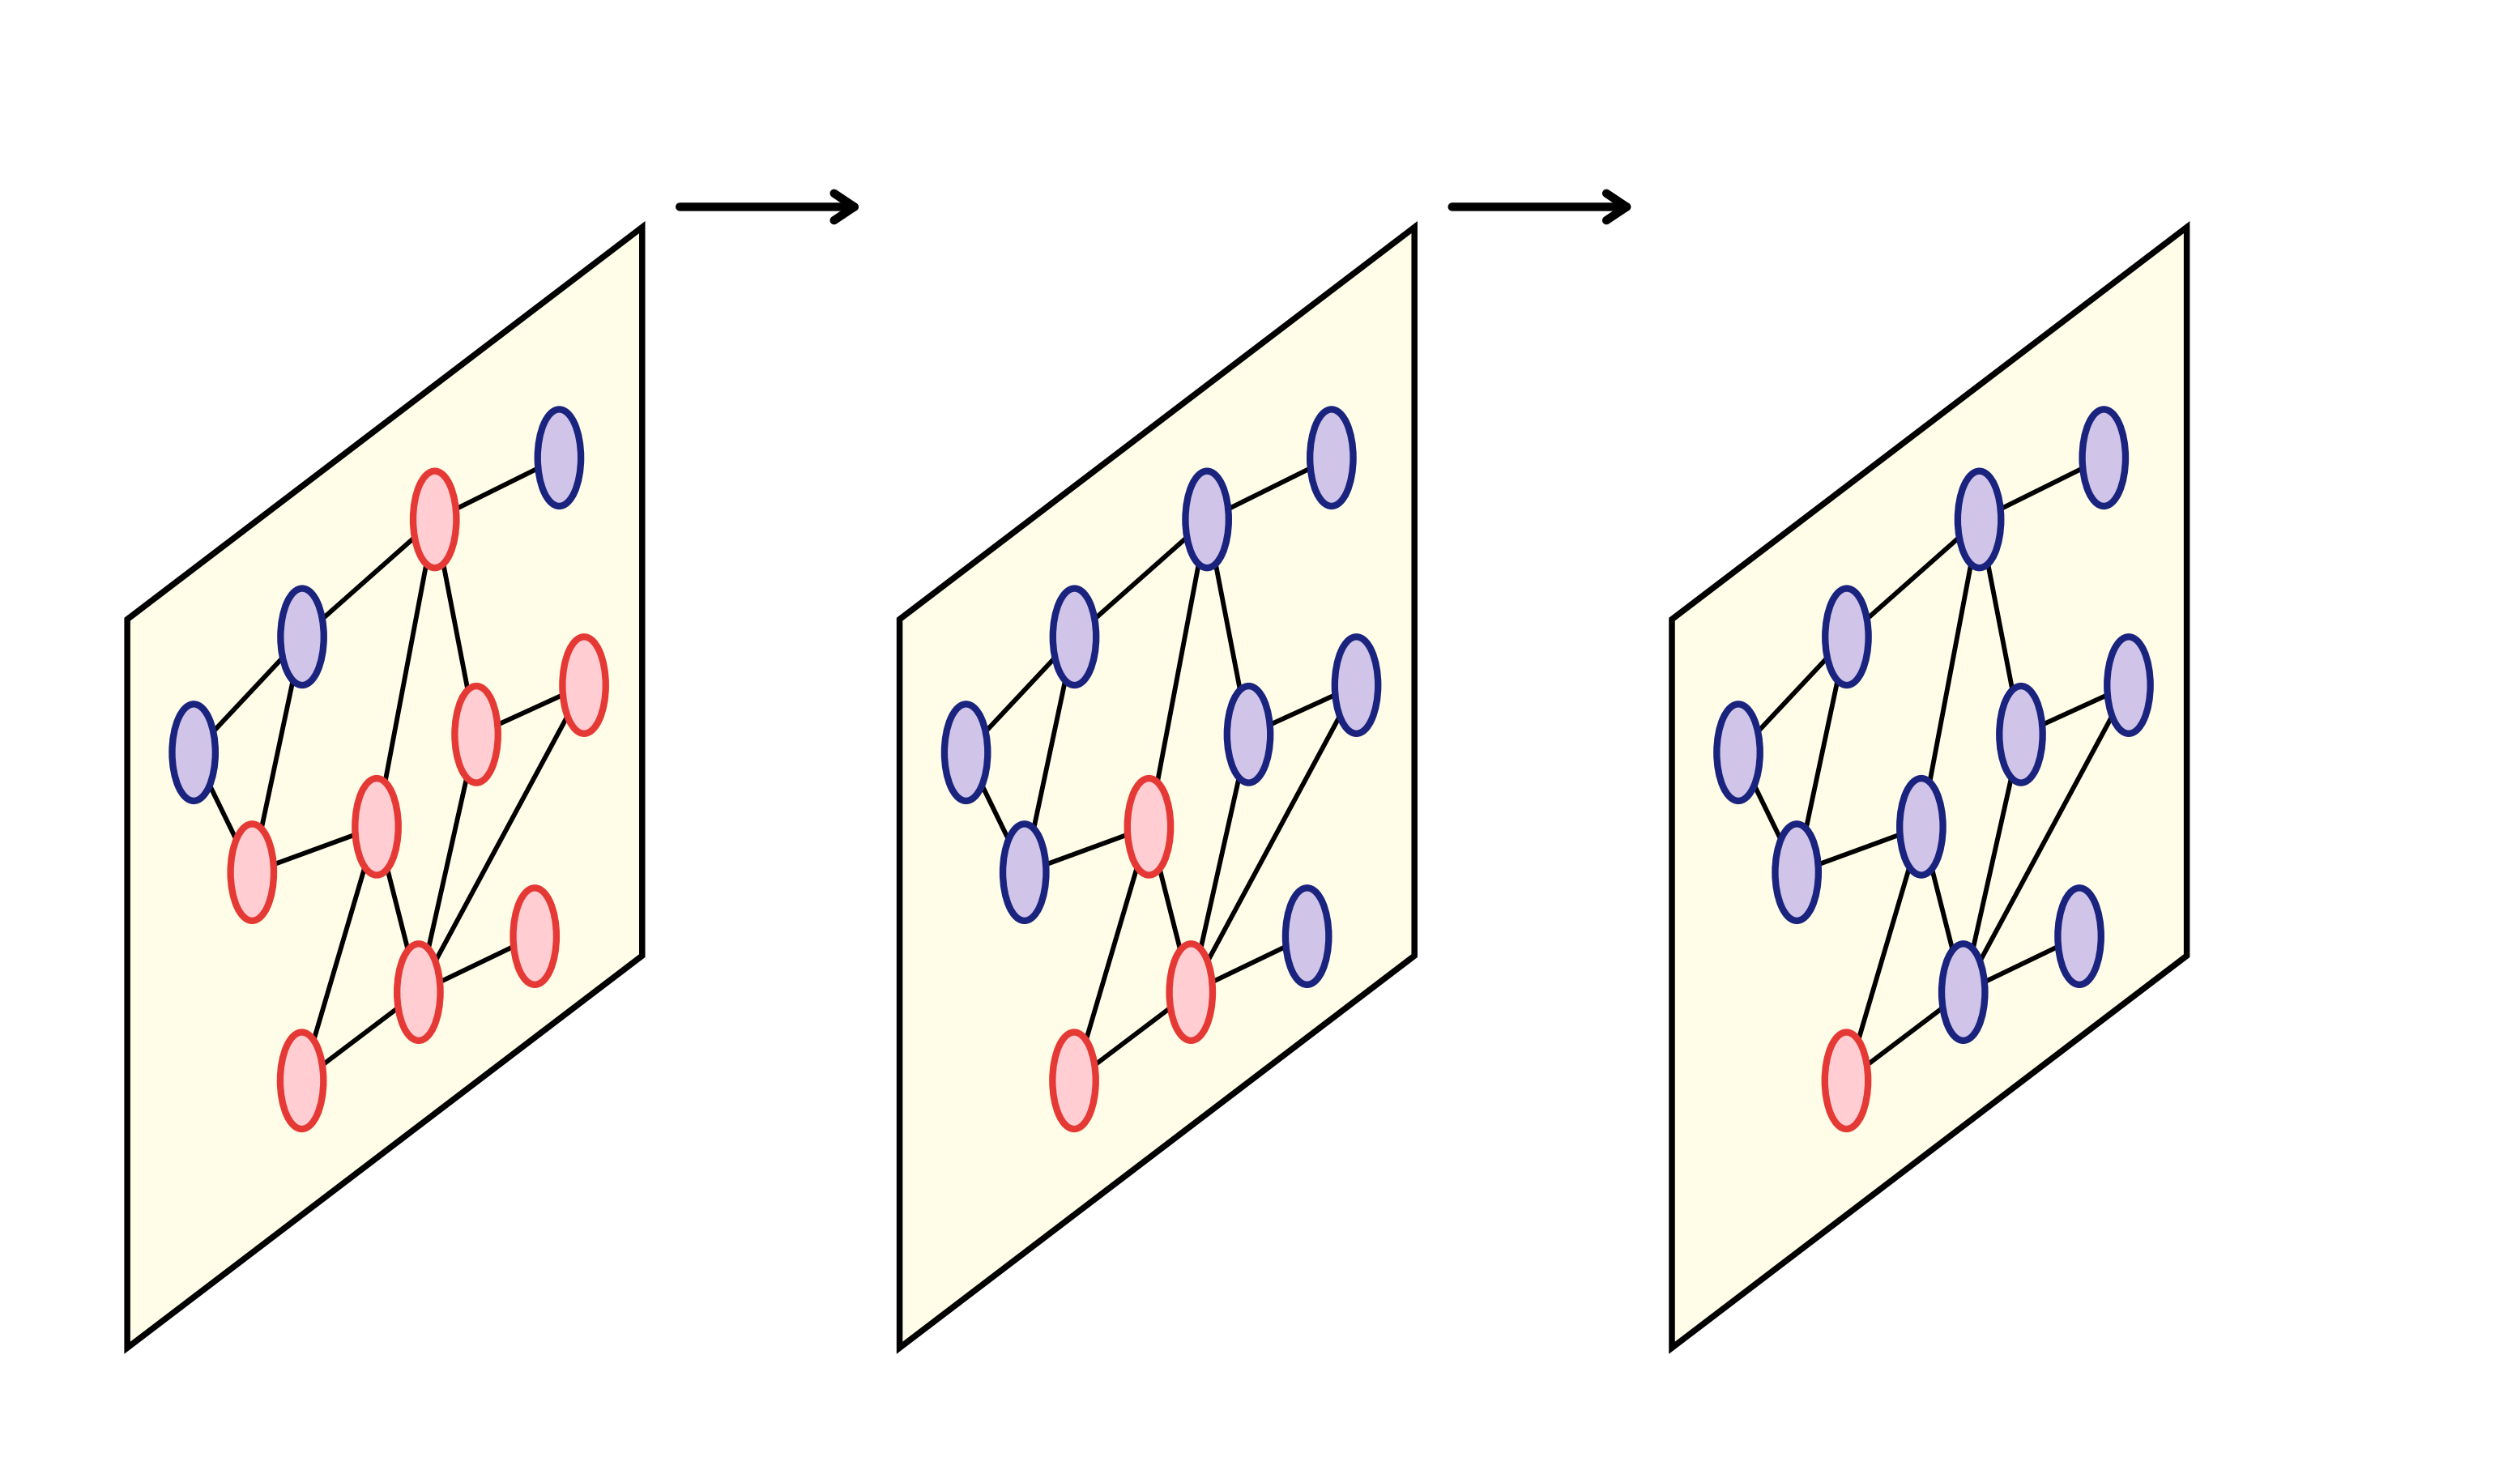

In [4]:
# 教科書 図 13.4 の生成と表示
fig13_4 = generate_figure_13_4()
plt.show()


In [5]:
# 受容野の拡大の数値計算 (Figure 13.4 の 11 ノードグラフ)
_, _, A_fig13_4 = create_figure_13_4_graph()
target_node = 10

receptive_fields = compute_receptive_field(A_fig13_4, target_node, max_hops=3)

print("=== 受容野の層方向拡大 (ホップ数別到達ノード) ===")
for hop, rf in enumerate(receptive_fields):
    print(f"層 l = {3 - hop} (ホップ数 {hop}): 赤色ノード数 {len(rf):2d} / 11 -> ノードID: {sorted(list(rf))}")

assert len(receptive_fields[0]) == 1, "Hop 0 must be 1 node"
assert len(receptive_fields[1]) == 3, "Hop 1 must be 3 nodes (Figure 13.4 plane 2)"
assert len(receptive_fields[2]) == 8, "Hop 2 must be 8 nodes (Figure 13.4 plane 1)"
print("ホップ数 0 -> 1 -> 2 における受容野拡大 (1 -> 3 -> 8 ノード) の完全一致を確認しました。")


=== 受容野の層方向拡大 (ホップ数別到達ノード) ===
層 l = 3 (ホップ数 0): 赤色ノード数  1 / 11 -> ノードID: [10]
層 l = 2 (ホップ数 1): 赤色ノード数  3 / 11 -> ノードID: [np.int64(6), np.int64(9), 10]
層 l = 1 (ホップ数 2): 赤色ノード数  8 / 11 -> ノードID: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), 10]
層 l = 0 (ホップ数 3): 赤色ノード数 11 / 11 -> ノードID: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), 10]
ホップ数 0 -> 1 -> 2 における受容野拡大 (1 -> 3 -> 8 ノード) の完全一致を確認しました。


---
## 13.2.4 更新演算子 (Update Operators)

### 1. 更新演算子の数式定義
集約メッセージ $\mathbf{z}_n^{(l)}$ と自己の表現 $\mathbf{h}_n^{(l)}$ を結合する更新演算子として、以下の形式が広く用いられます：

1. **線形結合更新** (式 13.16):
   $$
   \mathbf{h}_n^{(l+1)} = \text{Update}(\mathbf{h}_n^{(l)}, \mathbf{z}_n^{(l)}) = f\left( W_{\text{self}} \mathbf{h}_n^{(l)} + W_{\text{neigh}} \mathbf{z}_n^{(l)} + \mathbf{b} \right) \tag{13.16}
   $$

2. **重み共有更新** (式 13.17):
   自己と近傍で重み行列を共有 ($W_{\text{self}} = W_{\text{neigh}}$) し、和集約と組み合わせる場合：
   $$
   \mathbf{h}_n^{(l+1)} = f\left( W_{\text{neigh}} \sum_{m \in \mathcal{N}(n) \cup \{n\}} \mathbf{h}_m^{(l)} + \mathbf{b} \right) \tag{13.17}
   $$

3. **行列表現による多層変換** (式 13.18, 13.19):
   全ノードの埋め込みを行列 $H^{(l)} \in \mathbb{R}^{N \times D_l}$（$n$ 行目が $(\mathbf{h}_n^{(l)})^T$）にまとめると、多層GNNの層変換は次のように簡潔に行列積で記述できます：
   $$
   H^{(l+1)} = F\left( H^{(l)}, A, W^{(l+1)} \right) = \sigma\left( \widetilde{A}_{\text{norm}} H^{(l)} W^{(l)} + \mathbf{b} \right) \tag{13.18}
   $$
   置換行列 $P$ によるノードの並べ替えのもとで、層変換は置換同変性を満たします（式 13.19）：
   $$
   P H^{(l)} = F\left( P H^{(l-1)}, P A P^T, W^{(l)} \right) \tag{13.19}
   $$


In [6]:
# 式 (13.19) の層レベル置換同変性検証
edges = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (1, 3)]
rng = np.random.RandomState(42)
X = rng.randn(5, 4)
graph = Graph(num_nodes=5, edges=edges, node_features=X, is_directed=False)

layer = MessagePassingLayer(in_dim=4, out_dim=6, aggregate_type="norm", update_type="linear", seed=10)
perm = [3, 0, 4, 1, 2]
P = build_permutation_matrix(perm)

is_equiv = check_mpnn_permutation_equivariance(layer, graph, P=P)
print(f"MessagePassingLayer 置換同変性 (式 13.19) の成立: {is_equiv}")
assert is_equiv, "MessagePassingLayer must be permutation equivariant!"


MessagePassingLayer 置換同変性 (式 13.19) の成立: True


---
## 13.2.5 ノード分類 (Node Classification)

### 1. タスク定式化とソフトマックス出力層
ノード分類は GNN の最も代表的な応用です。最終層 $L$ のノード埋め込み $\mathbf{h}_n^{(L)}$ に対し、$C$ クラスの事後確率を出力するソフトマックス読み出し層を適用します（式 13.20）：

$$
y_{ni} = \frac{\exp\left( \mathbf{w}_i^T \mathbf{h}_n^{(L)} + b_i \right)}{\sum_{j=1}^C \exp\left( \mathbf{w}_j^T \mathbf{h}_n^{(L)} + b_j \right)} \tag{13.20}
$$

### 2. 半教師あり損失関数
訓練対象のラベル付きノード部分集合を $\mathcal{V}_{\text{train}}$ とし、交差エントロピー損失を最小化します（式 13.21）：

$$
\mathcal{L} = - \sum_{n \in \mathcal{V}_{\text{train}}} \sum_{i=1}^C t_{ni} \ln y_{ni} \tag{13.21}
$$

### 3. ノード分割の 3 分類
1. **訓練ノード $\mathcal{V}_{\text{train}}$**: ラベルが付与されており、メッセージパッシングと損失関数の評価の両方に参加。
2. **導入的ノード $\mathcal{V}_{\text{trans}}$ (Transductive)**: 訓練時にはラベル未知だが、グラフ構造（隣接行列）としてメッセージパッシングには参加。半教師あり学習。
3. **帰納的ノード $\mathcal{V}_{\text{induct}}$ (Inductive)**: 訓練時にはエッジも含めて完全に未知。推論時に初めてメッセージパッシングに参加。


訓練ノード正解率: 100.0% (4 ノード)
未見ノード (Transductive) 正解率: 100.0% (30 ノード)


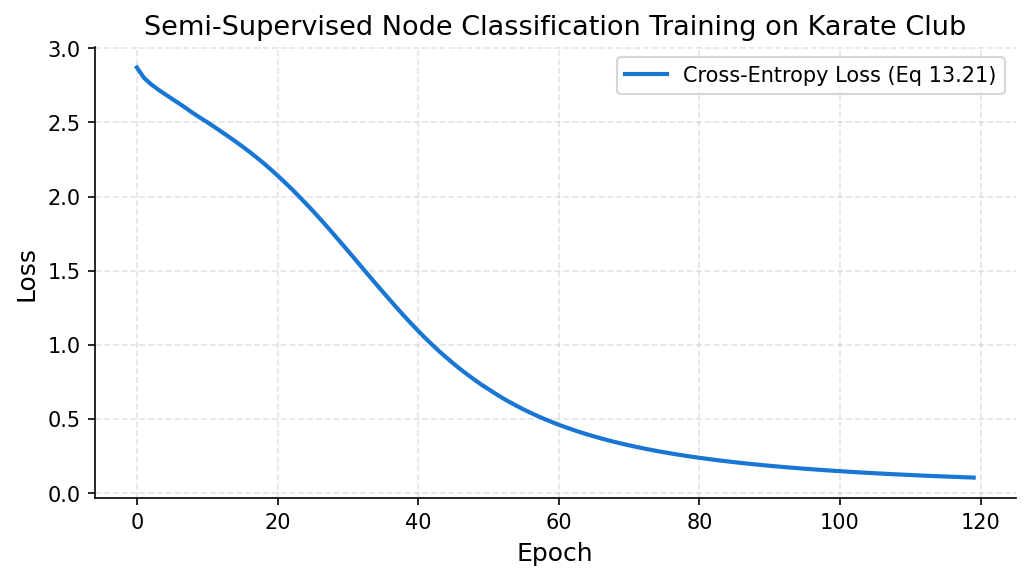

In [7]:
# Zachary's Karate Club グラフに対する半教師ありノード分類実験
karate_graph, karate_labels = create_karate_club_graph()
N = karate_graph.num_nodes

# One-hot targets
T = np.zeros((N, 2))
for i, c in enumerate(karate_labels):
    T[i, c] = 1.0

# 訓練ノード: 各クラスわずか 2 ノード（合計 4 ノードのみ教示）
train_mask = np.zeros(N, dtype=bool)
train_mask[[0, 1, 32, 33]] = True
test_mask = ~train_mask

model = NodeClassifier(in_dim=N, hidden_dims=[16], num_classes=2, seed=42)
loss_history = model.fit(karate_graph.A, karate_graph.node_features, T, train_mask, epochs=120, lr=0.08)

# 推論
preds = model.predict(karate_graph.A, karate_graph.node_features)
train_acc = np.mean(preds[train_mask] == karate_labels[train_mask])
test_acc = np.mean(preds[test_mask] == karate_labels[test_mask])

print(f"訓練ノード正解率: {train_acc * 100:.1f}% ({np.sum(train_mask)} ノード)")
print(f"未見ノード (Transductive) 正解率: {test_acc * 100:.1f}% ({np.sum(test_mask)} ノード)")

# 損失推移プロット
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.plot(loss_history, color="#1976d2", linewidth=2.0, label="Cross-Entropy Loss (Eq 13.21)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Semi-Supervised Node Classification Training on Karate Club")
ax.legend()
plt.tight_layout()
plt.show()


---
## 13.2.6 エッジ分類・リンク予測 (Edge Classification)

ノード埋め込み $\mathbf{h}_n^{(L)}, \mathbf{h}_m^{(L)}$ から、ノード $n$ と $m$ の間にエッジが存在する確率（リンク予測）をロジスティックシグモイド関数を用いてモデル化します（式 13.22）：

$$
p(n, m) = \sigma\left( (\mathbf{h}_n^{(L)})^T \mathbf{h}_m^{(L)} \right) \tag{13.22}
$$

より一般には、学習可能な双線形行列 $W_{\text{edge}}$ を用いた $p(n, m) = \sigma(\mathbf{h}_n^T W_{\text{edge}} \mathbf{h}_m)$ や、ペアの結合ベクトルに対する MLP も利用されます。


In [8]:
# エッジ分類・リンク予測モデルの評価
edge_clf = EdgeClassifier(embed_dim=16, use_bilinear=False)

# GCN 隠れ層 (dim 16) のノード埋め込みからリンク確率行列を計算
activations, _, _ = model.forward(
    GraphConvolutionalNetwork.compute_normalized_adjacency(karate_graph.A),
    karate_graph.node_features
)
gcn_embeds = activations[1]  # (34, 16)

prob_matrix = edge_clf.predict_matrix(gcn_embeds)

# 既存エッジと非エッジにおける平均予測確率
existing_edges = karate_graph.A > 0
non_edges = (karate_graph.A == 0) & (~np.eye(N, dtype=bool))

print(f"既存エッジ (陽例) に対する平均接続確率: {np.mean(prob_matrix[existing_edges]):.4f}")
print(f"非エッジ (陰例) に対する平均接続確率: {np.mean(prob_matrix[non_edges]):.4f}")
assert np.mean(prob_matrix[existing_edges]) > np.mean(prob_matrix[non_edges]), "Positive edges should have higher probability"


既存エッジ (陽例) に対する平均接続確率: 0.7271
非エッジ (陰例) に対する平均接続確率: 0.6651


---
## 13.2.7 グラフ分類 (Graph Classification)

グラフ全体に対する予測（分子の毒性分類、溶解度回帰など）では、全ノードの最終埋め込みをノード順序に不変な方法で集約（Global Readout Pooling）します（式 13.23）：

$$
\mathbf{y} = f\left( \sum_{n \in \mathcal{V}} \mathbf{h}_n^{(L)} \right) \tag{13.23}
$$

ここで $f(\cdot)$ は MLP などの学習可能な非線形関数です。和プーリングのほか、平均プーリングや要素ごと最大値プーリングも使用されます。


In [9]:
# グラフ全体予測と置換不変性の検証
graph_clf = GraphClassifier(node_embed_dim=4, readout_dims=[8, 2], pool_type="sum", seed=42)

# サンプルノード埋め込み
H_graph = np.random.RandomState(42).randn(8, 4)
perm = np.random.RandomState(99).permutation(8)
P_graph = build_permutation_matrix(perm)

y_orig = graph_clf.forward(H_graph)
y_perm = graph_clf.forward(P_graph @ H_graph)

print(f"元ノード順序でのグラフ出力: {y_orig}")
print(f"置換後ノード順序でのグラフ出力: {y_perm}")
print(f"出力の最大差分: {np.max(np.abs(y_orig - y_perm)):.6e}")
assert np.allclose(y_orig, y_perm), "Graph classification readout must be strictly permutation invariant!"


元ノード順序でのグラフ出力: [-3.03146177  1.5229378 ]
置換後ノード順序でのグラフ出力: [-3.03146177  1.5229378 ]
出力の最大差分: 4.440892e-16


---
## まとめと次節 13.3（一般化グラフネットワーク）への展望

本ノートブックでは、Bishop (2024) 第13章第13.2節「ニューラル・メッセージパッシング」の全体系を網羅しました：
1. **畳み込みフィルタ (13.2.1)**: 画像CNNから近傍共有重み $w_{\text{neigh}}$ と自己重み $w_{\text{self}}$ を持つグラフ同変畳み込みへの発展（式 13.8, 13.9, 図 13.3）。
2. **メッセージパッシングの基本枠組み (13.2.2)**: 集約 (Aggregate, 式 13.10) と更新 (Update, 式 13.11) の 2 段階反復構造 (Algorithm 13.1)。
3. **集約演算子と受容野 (13.2.3)**: 和・平均・正規化・最大値・Deep Sets (式 13.12 〜 13.15) と層方向受容野拡大（図 13.4）。
4. **更新演算子と多層GCN (13.2.4)**: 線形更新、重み共有更新、行列積表現と置換同変性 (式 13.16 〜 13.19)。
5. **ノード・エッジ・グラフ予測タスク (13.2.5 〜 13.2.7)**: 半教師ありノード分類 (式 13.20, 13.21)、リンク予測 (式 13.22)、大域プーリング (式 13.23)。

次節 **13.3 一般化グラフネットワーク (General Graph Networks)** では、アテンション重み付け集約を行うグラフアテンションネットワーク (GAT)、エッジ埋め込みとグラフ埋め込みを同時に更新する一般化MPNN (Algorithm 13.2, 図 13.5)、および過剰平滑化 (Over-smoothing) の回避手法について探究します。
